# Proyecto: Clasificación de reciclaje con MobileNetV2

Entrenar un modelo con las clases:

- Cardboard
- glass
- metal
- paper
- plastic
- trash

Al final guardara el modelo y las clases para usarlo en Streamlit.

In [1]:
!pip install tensorflow numpy pillow matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from kagglehub import dataset_download
dataset_path = dataset_download("saumyamohandas/garbage-classification-image-dataset")
print("Ruta del dataset: ", dataset_path)

Ruta del dataset:  C:\Users\JC\.cache\kagglehub\datasets\saumyamohandas\garbage-classification-image-dataset\versions\1


In [3]:
import os

for folder in os.listdir(dataset_path):
  print(folder)

dataset


In [4]:
import tensorflow as tf

train_data_path = os.path.join(dataset_path, 'dataset', 'Training')
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_data_path,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names
print(class_names)

Found 2508 files belonging to 6 classes.


['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


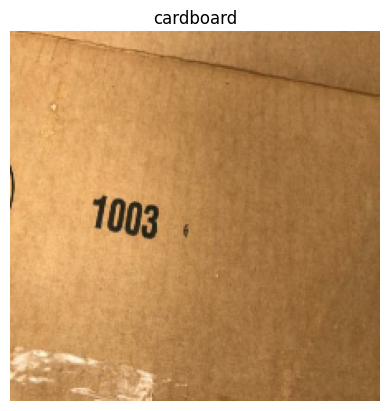

In [5]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
  plt.imshow(images[0].numpy().astype("uint8"))
  plt.title(class_names[labels[0]])
  plt.axis("off")

In [6]:
# importar mas librerias
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
OUTPUT_DIR = Path("modelo_reciclaje_mobilenet")
OUTPUT_DIR.mkdir(exist_ok=True)

# definir DATA_DIR AL PATH DE KAGGLEHUB DOWNLOAD
Data_DIR = os.path.join(dataset_path, 'dataset')

train_data_path = os.path.join(Data_DIR, 'Training')
val_data_path = os.path.join(Data_DIR, 'Testing')

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_data_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_data_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

class_names = train_ds.class_names
print('Clases detectadas: ',class_names)

Found 2508 files belonging to 6 classes.


Found 464 files belonging to 6 classes.


Clases detectadas:  ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


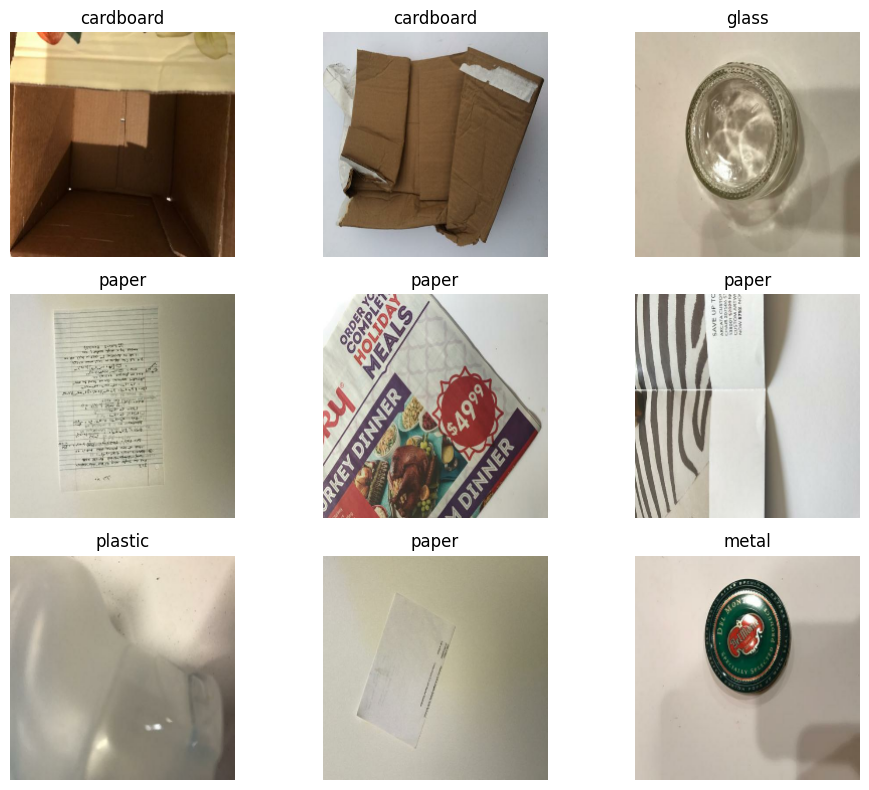

In [8]:
# hacer una matriz de 3x3
plt.figure(figsize=(10, 8))
for images, labels in train_ds.take(1):
  for i in range(min(9, len(images))):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype('uint8'))
    plt.title(class_names[labels[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

Este fragmento de código prepara los conjuntos de datos de entrenamiento (train_ds) y validación (val_ds) para ser utilizados por un modelo MobileNetV2 en TensorFlow. Primero, AUTOTUNE = tf.data.AUTOTUNE permite que TensorFlow optimice automáticamente el uso de recursos al cargar los datos. Luego, preprocess_input aplica el preprocesamiento específico de MobileNetV2, transformando los valores de los píxeles de las imágenes al formato esperado por esta red neuronal. Con map(), cada imagen (x) se convierte al tipo float32 mediante tf.cast() y posteriormente se preprocesa, mientras que las etiquetas (y) permanecen sin cambios. Finalmente, prefetch(AUTOTUNE) carga los siguientes lotes de datos en segundo plano mientras el modelo está entrenando, mejorando el rendimiento y reduciendo los tiempos de espera durante el entrenamiento.

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)).prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)).prefetch(AUTOTUNE)

##Crear un modelo de clasificación de imágenes basado en MobileNetV2 preentrenada en ImageNet.

- La red base se mantiene congelada para aprovechar sus características aprendidas, y se agregan nuevas capas para clasificar las imágenes en las categorías definidas.

- Finalmente, el modelo se compila usando el optimizador Adam y la métrica de precisión (accuracy) para su entrenamiento y evaluación.

In [10]:
#Crear el modelo MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

##Entrenar

Para probar rápido usa EPOCHS = 1.

In [11]:
#Earlystopping: detiene el entrenamiento cuando ve que ya no aprende
#Si con 2 EPOCH consecutivas no aprende el modelo, lo va a detener.
EPOCHS = 1

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

 1/79 ━━━━━━━━━━━━━━━━━━━━ 9:12 7s/step - accuracy: 0.3438 - loss: 2.0342

 2/79 ━━━━━━━━━━━━━━━━━━━━ 22s 295ms/step - accuracy: 0.3203 - loss: 1.9910

 3/79 ━━━━━━━━━━━━━━━━━━━━ 22s 290ms/step - accuracy: 0.3108 - loss: 1.9685

 4/79 ━━━━━━━━━━━━━━━━━━━━ 21s 287ms/step - accuracy: 0.2975 - loss: 1.9747

 5/79 ━━━━━━━━━━━━━━━━━━━━ 21s 285ms/step - accuracy: 0.2893 - loss: 1.9708

...

76/79 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.4693 - loss: 1.4037

77/79 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.4710 - loss: 1.3994

78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.4727 - loss: 1.3951

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.4744 - loss: 1.3909

79/79 ━━━━━━━━━━━━━━━━━━━━ 35s 358ms/step - accuracy: 0.6029 - loss: 1.0618 - val_accuracy: 0.7500 - val_loss: 0.7507


In [12]:
# evaluamos con 4 decimales
loss, acc = model.evaluate(val_ds, verbose=0)
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {acc:.4f}")

Loss: 0.7507
Accuracy: 0.7500


In [13]:
model.save(OUTPUT_DIR / "waste_mobilenet.h5")
#(HDF5 - Hierarchical Data Format version 5)
model.save(OUTPUT_DIR / "waste_mobilenet.keras")

with open(OUTPUT_DIR / "class_names.json", "w", encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

print("Modelo guardado en:", OUTPUT_DIR / "waste_mobilenet.h5")
print("Modelo guardado en:", OUTPUT_DIR / "waste_mobilenet.keras")
print("Clases guardadas en:", OUTPUT_DIR / "class_names.json")

Modelo guardado en: modelo_reciclaje_mobilenet\waste_mobilenet.h5
Modelo guardado en: modelo_reciclaje_mobilenet\waste_mobilenet.keras
Clases guardadas en: modelo_reciclaje_mobilenet\class_names.json


In [14]:
import tensorflow as tf

test_model = tf.keras.models.load_model(
    OUTPUT_DIR / "waste_mobilenet.h5",
    compile=False
)

print("Modelo cargado correctamente")
test_model.summary()

Modelo cargado correctamente


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Metal: 25.64%
Plástico: 21.38%
Papel: 20.19%


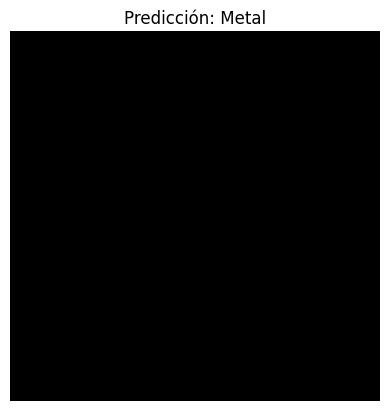

In [15]:
LABELS_ES= {
    "cardboard": "Cartón",
    "glass": "Vidrio",
    "metal": "Metal",
    "paper": "Papel",
    "plastic": "Plástico",
    "trash": "Basura",
}

def predict_image(img_path_param):
    img = Image.open(img_path_param).convert("RGB").resize(IMG_SIZE)
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)
    preds = test_model.predict(arr, verbose=0)[0]
    top3_idx = np.argsort(preds)[-3:][::-1]
    for idx in top3_idx:
        raw = class_names[idx]
        print(f"{LABELS_ES.get(raw, raw)}: {preds[idx]*100:.2f}%")
    return class_names[np.argmax(preds)]

# Probar con una imagen del dataset de validación
for images, labels in val_ds.take(1):
    test_img_path = "test_sample.jpeg"
    Image.fromarray(images[0].numpy().astype("uint8")).save(test_img_path)
    result = predict_image(test_img_path)
    plt.imshow(Image.open(test_img_path))
    plt.title(f"Predicción: {LABELS_ES.get(result, result)}")
    plt.axis("off")
    plt.show()
    break